<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/dogs%26Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 deadline 12 April 2026
Use Tensorflow and send your report to e-kursy
Do not send big files only:
A short analysis about this model, how it works and its advantages
with respect a simple multi-layer perceptron on one layer. The role of
the training rule. Results: some classified examples, training
duration, validation curves and test efficiency.
Download the program and related files from

**https://drive.google.com/drive/folders/1fFpRRh_FndQvrZMU-dusG-YmgrGXQeVK?usp=sharing**

Feedforward Neural Network
To classify dogs and cats.
Architecture:
- Input layer (Image vector)
- 3 fully connected hidden layers
- Output layer (According to the number of classes)
Tested on:
- Ubuntu 16.04
- Python 3.5 and 3.7
Requirements:
- Matpotlib: pip3 install matplotlib
- OpenCV: pip3 install opencv-python
- TensorFlow 1.15 (Release for CPU-only): pip3 install
tensorflow =1.15

In [1]:
import tensorflow.compat.v1 as tf
import numpy as np
import cv2 # do obróbki zdjęć
from google.colab.patches import cv2_imshow
import os


In [2]:
tf.disable_v2_behavior() #wymuszenie starej wersji tf

#path to model
model_path = '/content/drive/MyDrive/NN/nn_model/my_model-912'

#uruchomienie sesji
session = tf.Session()

#wczytanie struktury (grafu)
saver = tf.train.import_meta_graph(model_path + '.meta')

#wczytanie wag
saver.restore(session, model_path)


Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
#sprawdzanie nazw warstw
print([n.name for n in tf.get_default_graph().as_graph_def().node if "Placeholder" in n.op or "Softmax" in n.name])


['Placeholder', 'Placeholder_1', 'Placeholder_2', 'Placeholder_3', 'SparseSoftmaxCrossEntropyWithLogits/Shape', 'SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits', 'Softmax', 'Softmax_1', 'gradients/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits_grad/PreventGradient', 'gradients/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits_grad/ExpandDims/dim', 'gradients/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits_grad/ExpandDims', 'gradients/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits_grad/mul', 'save/filename', 'save/Const']


Model oczekuje wejścia o kształcie: (1000, 64, 64, 3)
Wynik dla piesek4.png: Kot (Prawdopodobieństwo: 1.00)


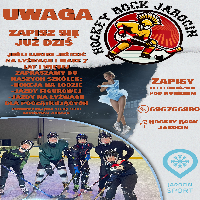

In [6]:
graph = tf.get_default_graph()
input_tensor = graph.get_tensor_by_name("Placeholder:0")
output_tensor = graph.get_tensor_by_name("Softmax:0")

print("Model oczekuje wejścia o kształcie:", input_tensor.shape)

def classify_image(image_path):
    # Wczytanie obrazu
    image = cv2.imread(image_path)
    if image is None:
        print(f"Nie znaleziono pliku: {image_path}")
        return

    # Zmiana rozmiaru na 64x64
    image_resized = cv2.resize(image, (64, 64))
    # Konwersja na RGB
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    # Normalizacja
    img_normalized = image_rgb.astype(np.float32) / 255.0

    # Model wymaga kształtu (1000, 64, 64, 3)
    # Tworzymy pusty batch o wymaganym rozmiarze
    input_batch = np.zeros((1000, 64, 64, 3), dtype=np.float32)
    # Wstawiamy nasze zdjęcie jako pierwszy element
    input_batch[0] = img_normalized

    try:
        # Placeholder_1, 2, 3 to prawdopodobnie parametry uczenia/dropoutu
        # Zazwyczaj przy inferencji ustawia się je na 1.0 lub 0
        feed_dict = {
            input_tensor: input_batch,
            "Placeholder_1:0": 1.0, # Często spotykane w starych modelach TF
            "Placeholder_2:0": 1.0,
            "Placeholder_3:0": 1.0
        }

        # Spróbujmy najpierw z samym wejściem, jeśli wywali błąd o braku Placeholder_1, dodamy je do feed_dict
        prediction = session.run(output_tensor, feed_dict={input_tensor: input_batch})

        # Wynik bierzemy tylko dla pierwszego obrazu z batcha
        first_prediction = prediction[0]
        label = "Pies" if np.argmax(first_prediction) == 1 else "Kot"

        print(f"Wynik dla {os.path.basename(image_path)}: {label} (Prawdopodobieństwo: {np.max(first_prediction):.2f})")
        cv2_imshow(cv2.resize(image, (200, 200)))
    except Exception as e:
        print(f"Błąd podczas inferencji: {e}")

# Test
test_img = '/content/drive/MyDrive/OLD/piesek4.png'
if os.path.exists(test_img):
    classify_image(test_img)
else:
    print("Podaj poprawną ścieżkę do obrazka.")

# ***Inferencja*** (przygotowywanie zdjęć)

Zakładamy że model przyjemuje paczke 1000 zdjęć, każde musi mieć rozmiar 64x64x3

